## Dataset 1: US Grants Dataset

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
grants = pd.read_csv("/content/grants.csv")
details = pd.read_csv("/content/grant_opportunity_details.csv")

df = grants.merge(details, on="opportunity_id", how="left")

/tmp/ipython-input-1607563133.py:1: DtypeWarning: Columns (6,8,10,11) have mixed types. Specify dtype option on import or set low_memory=False.
  grants = pd.read_csv("/content/grants.csv")


In [3]:
df.shape
df.head()
df.isna().mean().sort_values(ascending=False).head(10)

,0
opportunity_category_explanation,0.999290
category_explanation,0.997897
estimated_post_date,0.993076
estimated_application_due_date,0.992313
expected_number_of_awards_y,0.991710
award_floor,0.991348
agency_contact_phone,0.991054
estimated_total_program_funding,0.990826
award_ceiling,0.985617
archive_date,0.977943


### Q1 Eligibility Structure & Accessibility
Do grant opportunities differ systematically in how eligibility requirements co-occur, and what do these patterns imply about access?

In [4]:
elig_cols = [c for c in df.columns if c.startswith("eligibility_")]
elig_df = df[elig_cols]

In [5]:
elig_df.mean().sort_values()

,0
eligibility_individuals,0.0155
eligibility_unrestricted,0.15
eligibility_public_indian_housing_authorities,0.463
eligibility_for_profit,0.4685
eligibility_native_american_tribal_organizations_other,0.49
eligibility_special_district_governments,0.4965
eligibility_small_businesses,0.4975
eligibility_nonprofits_non_501c3,0.502
eligibility_city_or_township_governments,0.5085
eligibility_county_governments,0.509


Eligibility is not evenly distributed across applicant types; instead, it reflects a structural bias toward institutional actors, with individuals largely excluded.

### Q1 Eligibility co-occurrence

Do federal grant opportunities differ systematically in how eligibility requirements are bundled across applicant types, and what do these eligibility regimes imply about which organizations are realistically positioned to access public funding?

In [8]:
corr = elig_df.corr()

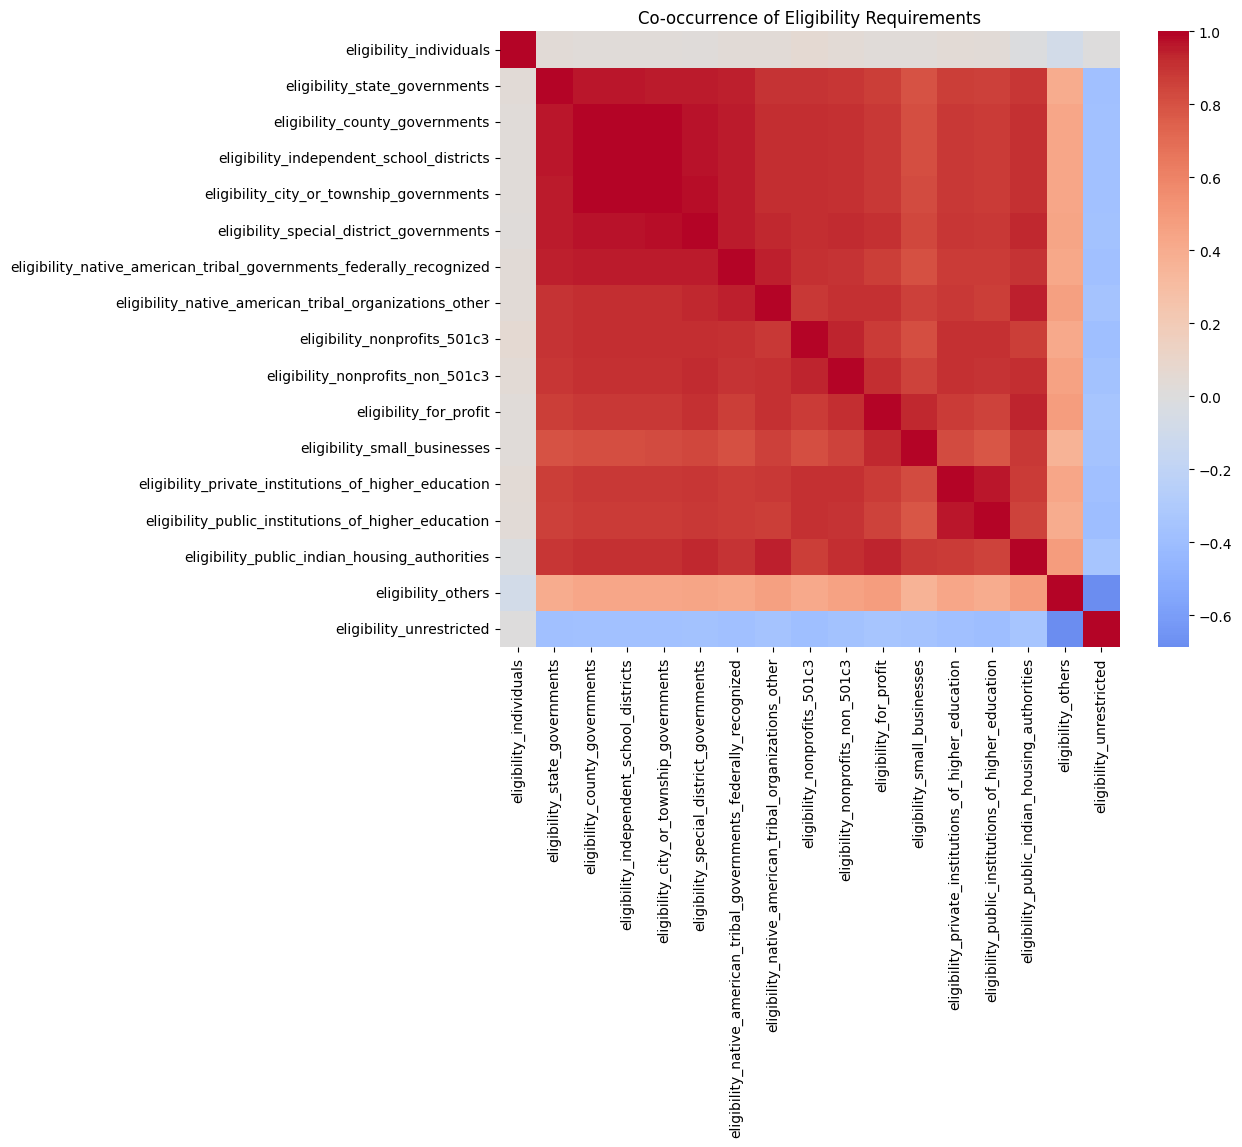

In [9]:
plt.figure(figsize=(10,8))
sns.heatmap(corr, cmap="coolwarm", center=0)
plt.title("Co-occurrence of Eligibility Requirements")
plt.show()

Preliminary EDA suggests that eligibility criteria rarely vary independently. Instead, eligibility flags form distinct, highly correlated bundles particularly among government and institutional applicants while “unrestricted” opportunities appear structurally distinct. This indicates that access to federal grants is shaped less by isolated requirements and more by coherent eligibility regimes.

### Q2 Funding Size vs Administrative Complexity

Q: Do higher-value federal grant opportunities exhibit  different eligibility breadth than lower-value opportunities, and what does this suggest about the trade-offs between grant size and accessibility for potential applicants?



In [14]:
g2_df = df[
    df["estimated_total_program_funding"].notna() &
    (df["estimated_total_program_funding"] > 0)
].copy()

g2_df["log_funding"] = np.log10(g2_df["estimated_total_program_funding"])

In [15]:
g2_df.shape
g2_df["log_funding"].describe()

,log_funding
count,657.000000
mean,6.992981
std,0.888684
min,4.301030
25%,6.477121
50%,7.000000
75%,7.477121
max,10.145196


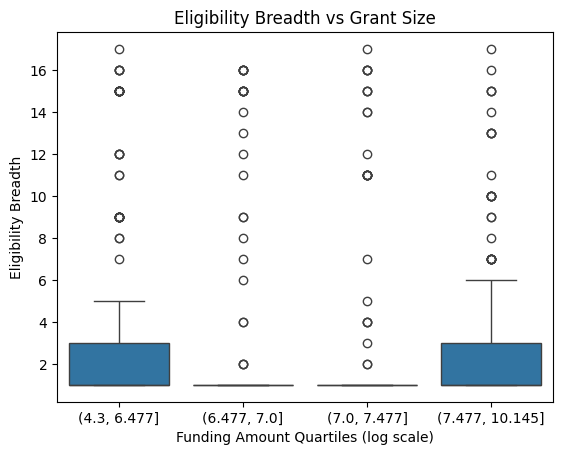

In [16]:
sns.boxplot(
    data=g2_df,
    x=pd.qcut(g2_df["log_funding"], q=4, duplicates="drop"),
    y="eligibility_count"
)
plt.xlabel("Funding Amount Quartiles (log scale)")
plt.ylabel("Eligibility Breadth")
plt.title("Eligibility Breadth vs Grant Size")
plt.show()

Preliminary analysis indicates that higher funding amounts are not associated with broader eligibility. Across funding quartiles, eligibility breadth remains consistently low, suggesting that increased grant size does not translate into increased accessibility and may instead reflect greater administrative or institutional targeting.

## Dataset 2: European Drug Development

### Q1 Development Pathway Archetypes

Is drug development activity in Europe evenly distributed across therapeutic areas, or does it exhibit concentration patterns that suggest portfolio risk and prioritization trade-offs?

In [25]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

drugs = pd.read_csv("/content/drugs.csv")
drugs.shape
drugs.head()

,category,medicine_name,therapeutic_area,common_name,active_substance,product_number,patient_safety,authorisation_status,atc_code,additional_monitoring,...,marketing_authorisation_holder_company_name,pharmacotherapeutic_group,date_of_opinion,decision_date,revision_number,condition_indication,species,first_published,revision_date,url
0,human,Adcetris,"Lymphoma, Non-Hodgkin; Hodgkin Disease",brentuximab vedotin,brentuximab vedotin,2455,False,authorised,L01XC12,False,...,Takeda Pharma A/S,Antineoplastic agents,2012-07-19,2022-11-17,34.0,Hodgkin lymphomaAdcetris is indicated for adul...,NaN,2018-07-25T13:58:00Z,2023-03-13T11:52:00Z,https://www.ema.europa.eu/en/medicines/human/E...
1,human,Nityr,Tyrosinemias,nitisinone,nitisinone,4582,False,authorised,A16AX04,False,...,Cycle Pharmaceuticals (Europe) Ltd,"Other alimentary tract and metabolism products,",2018-05-31,2023-03-10,4.0,Treatment of adult and paediatric patients wit...,NaN,2018-07-26T14:20:00Z,2023-03-10T17:29:00Z,https://www.ema.europa.eu/en/medicines/human/E...
2,human,Ebvallo,Lymphoproliferative Disorders,tabelecleucel,tabelecleucel,4577,False,authorised,NaN,True,...,Pierre Fabre Medicament,NaN,2022-10-13,2023-03-09,2.0,Ebvallo is indicated as monotherapy for treatm...,NaN,2022-10-12T16:13:00Z,2023-03-10T13:40:00Z,https://www.ema.europa.eu/en/medicines/human/E...
3,human,Ronapreve,COVID-19 virus infection,"casirivimab, imdevimab","casirivimab, imdevimab",5814,False,authorised,J06BD,True,...,Roche Registration GmbH,"Immune sera and immunoglobulins,",2021-11-11,2023-02-24,3.0,Ronapreve is indicated for:Treatment of COVID-...,NaN,2021-11-12T16:30:00Z,2023-03-10T12:29:00Z,https://www.ema.europa.eu/en/medicines/human/E...
4,human,Cosentyx,"Arthritis, Psoriatic; Psoriasis; Spondylitis...",secukinumab,secukinumab,3729,False,authorised,L04AC10,False,...,Novartis Europharm Limited,Immunosuppressants,2014-11-20,2023-01-26,30.0,Plaque psoriasisCosentyx is indicated for the ...,NaN,2018-06-07T11:59:00Z,2023-03-09T18:53:00Z,https://www.ema.europa.eu/en/medicines/human/E...


In [26]:
drugs_ta = (
    drugs
    .dropna(subset=["therapeutic_area"])
    .assign(
        therapeutic_area=drugs["therapeutic_area"].str.split(";")
    )
    .explode("therapeutic_area")
)

drugs_ta["therapeutic_area"] = drugs_ta["therapeutic_area"].str.strip()

In [27]:
ta_counts = (
    drugs_ta
    .groupby("therapeutic_area")
    .size()
    .sort_values(ascending=False)
)

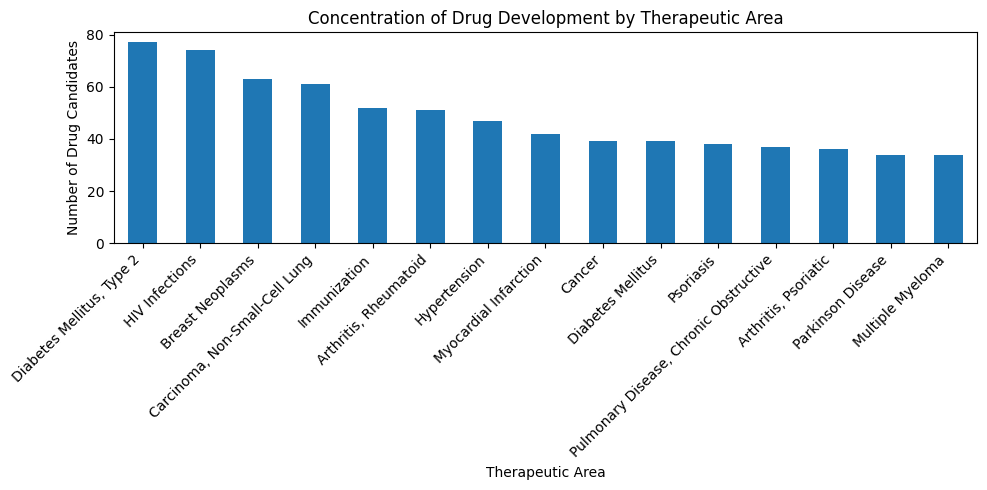

In [28]:
plt.figure(figsize=(10,5))
ta_counts.head(15).plot(kind="bar")
plt.title("Concentration of Drug Development by Therapeutic Area")
plt.ylabel("Number of Drug Candidates")
plt.xlabel("Therapeutic Area")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

Preliminary EDA reveals that European drug development activity is concentrated in a small number of therapeutic areas, with a long tail of conditions receiving comparatively limited attention. This concentration suggests that development efforts reflect prioritization and risk allocation decisions rather than broad diversification across disease areas.

### Q2 Regulatory Outcome Profiles by Therapeutic Area

Q2: Do drug candidates in European development programs exhibit distinct regulatory outcome profiles across therapeutic areas, and what do these differences suggest about variation in development pathways and uncertainty?

In [29]:
drugs_clean = drugs.dropna(subset=["authorisation_status", "therapeutic_area"])

In [30]:
drugs_path = (
    drugs_clean
    .assign(therapeutic_area=drugs_clean["therapeutic_area"].str.split(";"))
    .explode("therapeutic_area")
)

drugs_path["therapeutic_area"] = drugs_path["therapeutic_area"].str.strip()

In [31]:
top_areas = ta_counts.head(6).index

pathway_dist = (
    drugs_path[drugs_path["therapeutic_area"].isin(top_areas)]
    .groupby(["therapeutic_area", "authorisation_status"])
    .size()
    .reset_index(name="count")
)

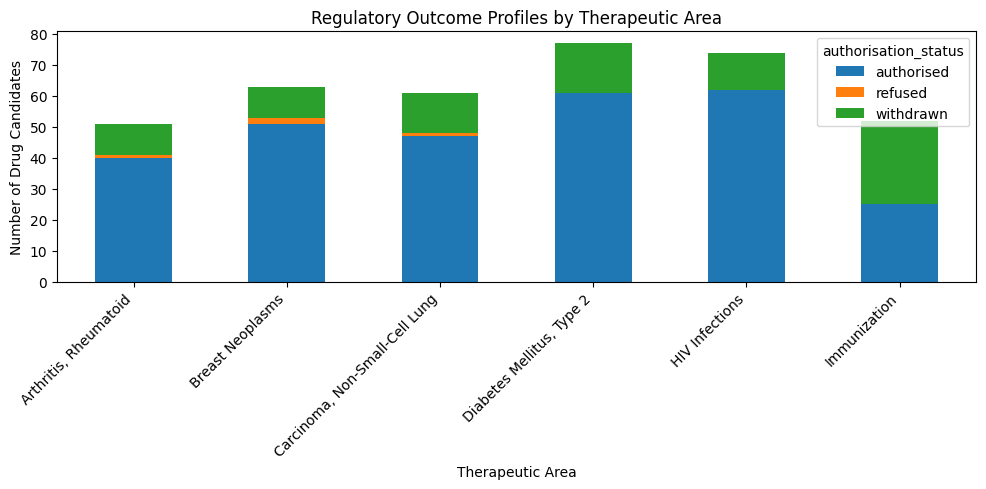

In [32]:
pivot = pathway_dist.pivot(
    index="therapeutic_area",
    columns="authorisation_status",
    values="count"
).fillna(0)

pivot.plot(
    kind="bar",
    stacked=True,
    figsize=(10,5)
)

plt.title("Regulatory Outcome Profiles by Therapeutic Area")
plt.ylabel("Number of Drug Candidates")
plt.xlabel("Therapeutic Area")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

Preliminary analysis indicates that therapeutic areas differ systematically in their regulatory outcome profiles. While some areas exhibit relatively high authorization rates and limited withdrawals, others show greater attrition, suggesting distinct development pathway archetypes characterized by varying levels of regulatory uncertainty and risk.